Performance_Fragmentomic model

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

In [ ]:
df=pd.read_csv(r"Performance fragmentomic model.csv",sep=',')
df.info()
df

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =============================
# 1. Label
# =============================
df = df.copy()
df['Label'] = df['Class'].isin(['CRC', 'PreC']).astype(int)
df['Prediction'] = df['Prediction'].astype(int)

# =============================
# 2. SEM function
# =============================
def proportion_sem(tp, n):
    if n == 0:
        return (np.nan, np.nan, np.nan)
    p = tp / n
    sem = np.sqrt(p * (1 - p) / n)
    return p, p - sem, p + sem

# =============================
# 3. Metric calculation
# =============================
def calculate_metrics(df_subset):
    results = {}

    # Healthy
    healthy = df_subset[df_subset['Class'] == 'Healthy']
    tn = (healthy['Prediction'] == 0).sum()
    n = len(healthy)
    results['Healthy'] = (*proportion_sem(tn, n), n)

    # PreK
    prek = df_subset[df_subset['Class'] == 'PreC']
    tp = (prek['Prediction'] == 1).sum()
    n = len(prek)
    results['PreC'] = (*proportion_sem(tp, n), n)

    # CRC
    crc = df_subset[df_subset['Class'] == 'CRC']
    tp = (crc['Prediction'] == 1).sum()
    n = len(crc)
    results['CRC'] = (*proportion_sem(tp, n), n)

    # Stage
    for stage in ['Stage I', 'Stage II', 'Stage III', 'Unknown stage']:
        sub = crc[crc['Stage'] == stage]
        tp = (sub['Prediction'] == 1).sum()
        n = len(sub)
        results[f'{stage}'] = (*proportion_sem(tp, n), n)

    return results

# =============================
# 4. Apply Train/Test
# =============================
final_results = []

for dataset in ['Training', 'Test']:
    df_sub = df[df['Dataset'] == dataset]
    metrics = calculate_metrics(df_sub)

    for metric, (mean, low, high, n) in metrics.items():
        final_results.append({
            'Dataset': dataset,
            'Metric': metric,
            'Mean': mean * 100,
            'Low': low * 100,
            'High': high * 100,
            'N': n
        })

df_results = pd.DataFrame(final_results)

# =============================
# 5. Plot
# =============================
plt.figure(figsize=(14,6))

metric_order = [
    'Healthy',
    'PreC',
    'CRC',
    'Stage I',
    'Stage II',
    'Stage III',
    'Unknown stage',
]

df_results['Metric'] = pd.Categorical(df_results['Metric'], categories=metric_order, ordered=True)
df_results = df_results.sort_values('Metric')

ax = sns.barplot(
    data=df_results,
    x='Metric',
    y='Mean',
    hue='Dataset',
    ci=None
)

# =============================
# 6. Error bar (SEM)
# =============================
for i, row in df_results.iterrows():
    x_pos = list(df_results['Metric'].cat.categories).index(row['Metric'])
    shift = -0.2 if row['Dataset'] == 'Train' else 0.2

    lower = row['Mean'] - row['Low']
    upper = row['High'] - row['Mean']

    plt.errorbar(
        x=x_pos + shift,
        y=row['Mean'],
        yerr=[[lower], [upper]],
        fmt='none',
        c='black',
        capsize=3
    )

# =============================
# 7. Label (no overlap)
# =============================
for p, (_, row) in zip(ax.patches, df_results.iterrows()):
    height = p.get_height()

    ax.text(
        p.get_x() + p.get_width()/2,
        height + 1.2,
        f"{height:.1f}\n(n={row['N']})",
        ha="center",
        fontsize=9
    )

# =============================
# 8. Format
# =============================
plt.xticks(rotation=45)
plt.ylabel("Percentage (%)")
plt.title("Model Performance (Mean ± SEM)")

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# =============================
# 9. Output
# =============================
df_results

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact
import seaborn as sns

# -----------------------------
# Prepare data
# -----------------------------
metric_order = [
    'Healthy',
    'PreC',
    'CRC',
    'Stage I',
    'Stage II',
    'Stage III',
    'Unknown stage'
]

df_plot = df_results.copy()
df_plot = df_plot[df_plot['Metric'].isin(metric_order)]

train_df = df_plot[df_plot['Dataset'] == 'Training'].set_index('Metric').reindex(metric_order)
test_df  = df_plot[df_plot['Dataset'] == 'Test'].set_index('Metric').reindex(metric_order)

train_vals = train_df['Mean'].values
test_vals  = test_df['Mean'].values

# =============================
# SEM ERROR BAR
# =============================
train_err = [
    train_vals - train_df['Low'].values,
    train_df['High'].values - train_vals
]

test_err = [
    test_vals - test_df['Low'].values,
    test_df['High'].values - test_vals
]

train_n = train_df['N'].values
test_n  = test_df['N'].values

# -----------------------------
# Statistical test (Fisher)
# -----------------------------
def get_counts(df_sub, cond):
    sub = df_sub[cond]
    tp = (sub['Prediction'] == 1).sum()
    fn = (sub['Prediction'] == 0).sum()
    return tp, fn

def get_tn_fp(df_sub, cond):
    sub = df_sub[cond]
    tn = (sub['Prediction'] == 0).sum()
    fp = (sub['Prediction'] == 1).sum()
    return tn, fp

def p_to_star(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'ns'

p_values = {}

for metric in metric_order:

    df_train = df[df['Dataset'] == 'Training']
    df_test  = df[df['Dataset'] == 'Test']

    if metric == 'Healthy':
        tn1, fp1 = get_tn_fp(df_train, df_train['Class'] == 'Healthy')
        tn2, fp2 = get_tn_fp(df_test,  df_test['Class'] == 'Healthy')
        table = [[tn1, fp1], [tn2, fp2]]

    elif metric == 'PreC':
        tp1, fn1 = get_counts(df_train, df_train['Class'] == 'PreC')
        tp2, fn2 = get_counts(df_test,  df_test['Class'] == 'PreC')
        table = [[tp1, fn1], [tp2, fn2]]

    elif metric == 'CRC':
        tp1, fn1 = get_counts(df_train, df_train['Class'] == 'CRC')
        tp2, fn2 = get_counts(df_test,  df_test['Class'] == 'CRC')
        table = [[tp1, fn1], [tp2, fn2]]

    elif '' in metric:
        stage = metric.replace('Sensitivity_', '')
        cond_train = (df_train['Class'] == 'CRC') & (df_train['Stage'] == stage)
        cond_test  = (df_test['Class'] == 'CRC') & (df_test['Stage'] == stage)

        tp1, fn1 = get_counts(df_train, cond_train)
        tp2, fn2 = get_counts(df_test, cond_test)
        table = [[tp1, fn1], [tp2, fn2]]

    else:
        p_values[metric] = np.nan
        continue

    try:
        _, p = fisher_exact(table)
    except:
        p = np.nan

    p_values[metric] = p

# -----------------------------
# Plot
# -----------------------------
x = np.arange(len(metric_order))
width = 0.35

fig=plt.figure(figsize=(15,7))

bars1 = plt.bar(x - width/2, train_vals, width,
                label='Training', color='skyblue',
                yerr=train_err, capsize=4)

bars2 = plt.bar(x + width/2, test_vals, width,
                label='Test', color='lightcoral',
                yerr=test_err, capsize=4)

# Mean dots
plt.scatter(x - width/2, train_vals, color='blue', zorder=3)
plt.scatter(x + width/2, test_vals, color='red', zorder=3)

# Sample size inside
for i in range(len(x)):
    if not np.isnan(train_vals[i]):
        plt.text(x[i] - width/2, train_vals[i]/2,
                 f"{int(train_n[i])}",
                 ha='center', va='center', fontsize=16)

    if not np.isnan(test_vals[i]):
        plt.text(x[i] + width/2, test_vals[i]/2,
                 f"{int(test_n[i])}",
                 ha='center', va='center', fontsize=16)

# % labels
offset = np.nanmax(df_results['Mean']) * 0.035

for i, bar in enumerate(bars1):
    height = bar.get_height()
    upper = train_df['High'].values[i]
    if not np.isnan(height):
        plt.text(bar.get_x() + bar.get_width()/2,
                 upper + offset,
                 f"{height:.1f}%",
                 ha='center', fontsize=16)

for i, bar in enumerate(bars2):
    height = bar.get_height()
    upper = test_df['High'].values[i]
    if not np.isnan(height):
        plt.text(bar.get_x() + bar.get_width()/2,
                 upper + offset,
                 f"{height:.1f}%",
                 ha='center', fontsize=16)

# -----------------------------
# Significance (no overlap)
# -----------------------------
for i, metric in enumerate(metric_order):

    p = p_values.get(metric, np.nan)
    star = p_to_star(p)

    y1 = train_df['High'].values[i]
    y2 = test_df['High'].values[i]
    y_base = max(y1, y2)

    y_percent = y_base + offset
    y_bracket = y_percent + offset * 1.5
    h = offset * 0.8

    x1 = x[i] - width/2
    x2 = x[i] + width/2

    plt.plot([x1, x1, x2, x2],
             [y_bracket, y_bracket + h, y_bracket + h, y_bracket],
             lw=1.5, c='black')

    plt.text((x1 + x2)/2,
             y_bracket + h + offset*0.5,
             star,
             ha='center',
             fontsize=16)

# -----------------------------
# Format
# -----------------------------
plt.xticks(x, metric_order)
plt.ylabel('Performance (%)', fontsize=22)
plt.title('Specificity and sensitivity of fragmentomic model', fontsize=24, fontweight='bold')
plt.tick_params(axis='x', labelsize=22)
plt.tick_params(axis='y', labelsize=22)
plt.ylim(0,115)
plt.legend(
    frameon=False,
    fontsize=20,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.03),
    ncol=2
)
sns.set(style="white", font_scale=1.2)
plt.rcParams.update({
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'axes.edgecolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black'
})
from matplotlib.ticker import MultipleLocator

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.yaxis.set_major_locator(MultipleLocator(10))
ax.tick_params(axis='both', length=6, width=1.5, left=True)
for spine in ['left', 'bottom']:
        plt.gca().spines[spine].set_linewidth(2)  # hoặc 2.5, 3

        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)
ax.spines['left'].set_visible(True)


plt.tight_layout()
plt.show()
fig.savefig(r"C:\Users\VANTHITUONGVI\OneDrive - Gene Solutions\Manuscript_SCED_CRC\Figure\Figure 5D.pdf", bbox_inches='tight')

Compare 1D vs. 2D

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

In [ ]:
df=pd.read_csv(r"Proba_CRC_01.08_CV10_train.csv")
df.info()
df.head()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from sklearn.metrics import roc_curve, roc_auc_score
from rocauc_comparison import delong_roc_test

mpl.rcParams["font.family"] = "Arial"


# ==========================================
# Bootstrap 95% CI for AUC
# ==========================================
def bootstrap_auc_ci(y_true, y_score, n_bootstrap=1000, seed=42):

    rng = np.random.RandomState(seed)
    aucs = []

    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)

    for _ in range(n_bootstrap):

        idx = rng.randint(0, len(y_true), len(y_true))

        if len(np.unique(y_true[idx])) < 2:
            continue

        aucs.append(roc_auc_score(y_true[idx], y_score[idx]))

    lower = np.percentile(aucs, 2.5)
    upper = np.percentile(aucs, 97.5)

    return lower, upper


# ==========================================
# Plot ROC
# ==========================================
def plot_roc_compare(ax, data, title):

    y_true = data["Label"].values

    pred1 = data["Model 1D"].values
    pred2 = data["Model 2D"].values

    # ROC
    fpr1, tpr1, _ = roc_curve(y_true, pred1)
    fpr2, tpr2, _ = roc_curve(y_true, pred2)

    auc1 = roc_auc_score(y_true, pred1)
    auc2 = roc_auc_score(y_true, pred2)

    # 95% CI
    ci1 = bootstrap_auc_ci(y_true, pred1)
    ci2 = bootstrap_auc_ci(y_true, pred2)

    # DeLong
    result = delong_roc_test(y_true, pred1, pred2)
    p_value = result.p_value

    # ROC curves
    ax.plot(
        fpr1,
        tpr1,
        lw=3.5,
        label=f"Model 1D = {auc1:.2f} (95% CI: {ci1[0]:.2f}-{ci1[1]:.2f})"
    )

    ax.plot(
        fpr2,
        tpr2,
        lw=3.5,
        label=f"Model 2D = {auc2:.2f} (95% CI: {ci2[0]:.2f}-{ci2[1]:.2f})"
    )

    # Dummy legend entry for DeLong p-value
    if p_value < 0.001:
        p_text = "DeLong test: p < 0.001"
    else:
        p_text = f"DeLong test: p = {p_value:.3f}"

    ax.plot([], [], ' ', label=p_text)

    # Diagonal
    ax.plot([0, 1], [0, 1],
            '--',
            color='gray',
            linewidth=2)

    # ax.set_xlim(0, 1)
    # ax.set_ylim(0, 1.02)

    ax.set_xlabel("1-Specificity", fontsize=22)
    ax.set_ylabel("Sensitivity", fontsize=22)
    ax.set_title(title, fontsize=24, fontweight='bold')

    legend = ax.legend(
        loc=4,
        fontsize=18,
        frameon=True,
        # handlelength=2
    )
    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_linewidth(0)
    legend.get_frame().set_alpha(0.5)   

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_linewidth(2)
    ax.spines["bottom"].set_linewidth(2)

    ax.tick_params(
        axis="both",
        labelsize=22,
        width=2,
        length=6
    )


# ==========================================
# Split datasets
# ==========================================
train = df[df["Dataset"] == "Training"].copy()
test = df[df["Dataset"] == "Test"].copy()


# ==========================================
# Plot
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

plot_roc_compare(axes[0], train, "Training")
plot_roc_compare(axes[1], test, "Test")

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# Training
# ==========================================
fig, ax = plt.subplots(figsize=(7, 7))

plot_roc_compare(ax, train, "Training")

plt.tight_layout()
plt.show()


# ==========================================
# Test
# ==========================================
fig, ax = plt.subplots(figsize=(7, 7))

plot_roc_compare(ax, test, "Test")

plt.tight_layout()
plt.show()

Complementary score

In [ ]:
df=pd.read_csv(r"Prediction_TMD.csv")
df.info()
df.head()

In [ ]:
import pandas as pd
import numpy as np

# ---------------------------
# 1. Define columns
# ---------------------------
base_col = 'Fragmentomic score'   # already 0/1
tmd_cols = [c for c in df.columns if c.startswith('TMD')]

# ---------------------------
# 2. Metric function
# ---------------------------
def calculate_metrics(df, y_pred):
    df_eval = df.copy()
    df_eval['y_pred'] = y_pred

    # Healthy
    healthy = df_eval[df_eval['Class'] == 'Healthy']
    spec_healthy = (healthy['y_pred'] == 0).mean() if len(healthy) > 0 else np.nan

    # PreK
    prek = df_eval[df_eval['Class'] == 'PreK']
    sens_prek = (prek['y_pred'] == 1).mean() if len(prek) > 0 else np.nan

    # CRC overall
    crc = df_eval[df_eval['Class'] == 'CRC']
    sens_crc = (crc['y_pred'] == 1).mean() if len(crc) > 0 else np.nan

    # CRC by stage
    def sens_stage(stage):
        subset = crc[crc['Stage'] == stage]
        return (subset['y_pred'] == 1).mean() if len(subset) > 0 else np.nan

    sens_crc_I = sens_stage('Stage I')
    sens_crc_II = sens_stage('Stage II')
    sens_crc_III = sens_stage('Stage III')
    sens_crc_NA = sens_stage('Stage NA')

    # Accuracy
    acc = (df_eval['y_pred'] == df_eval['Label']).mean()

    return {
        'Specificity_Healthy': spec_healthy,
        'Sensitivity_PreK': sens_prek,
        'Sensitivity_CRC': sens_crc,
        'Sens_CRC_Stage I': sens_crc_I,
        'Sens_CRC_Stage II': sens_crc_II,
        'Sens_CRC_Stage III': sens_crc_III,
        'Sens_CRC_Stage NA': sens_crc_NA,
        'Accuracy': acc
    }

# ---------------------------
# 3. V2 ONLY
# ---------------------------
results = []

y_pred_v2 = df[base_col].astype(int)
metrics_v2 = calculate_metrics(df, y_pred_v2)
metrics_v2['Model'] = 'V2 only'
metrics_v2['Cutoff_TMD'] = None

results.append(metrics_v2)

# ---------------------------
# 4. OR combinations
# ---------------------------
for tmd in tmd_cols:
    print(f"Processing OR with {tmd}")
    
    best = None
    
    for cutoff in np.linspace(df[tmd].min(), df[tmd].max(), 100):
        
        y_pred = (
            (df[base_col] == 1) |
            (df[tmd] >= cutoff)
        ).astype(int)

        metrics = calculate_metrics(df, y_pred)
        metrics['Model'] = f"V2 OR {tmd}"
        metrics['Cutoff_TMD'] = cutoff

        if best is None or metrics['Accuracy'] > best['Accuracy']:
            best = metrics

    results.append(best)

# ---------------------------
# 5. Final results
# ---------------------------
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='Accuracy', ascending=False)

results_df

In [ ]:
results_df.to_csv(r"Results_Complementary.csv",index=False)

Heatmap_Complementary score

In [ ]:
import pandas as pd

In [ ]:
df=pd.read_csv(r"Figure4_Heatmap_Combination_accuracy greater 0.csv")
df.info()
df.head()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------
# Prepare data
# ---------------------------
df_hm = df.set_index('Target name').T
n_rows = df_hm.shape[0]
n_cols = df_hm.shape[1]

# ---------------------------
# Scale (min-max + center=0)
# ---------------------------
scale_dict = {}

for row in df_hm.index:
    data = df_hm.loc[row]

    if row in ['Score_CRC+PreC', 'Score_PreK', 'Score_CRC']:
        max_abs = np.nanmax(np.abs(data))
        scale_dict[row] = (-max_abs, max_abs, 0)
    else:
        vmin = np.nanmin(data)
        vmax = np.nanmax(data)
        scale_dict[row] = (vmin, vmax, None)

# ---------------------------
# Dynamic figure size
# ---------------------------
fig_width = max(20, n_cols * 0.1)
fig = plt.figure(figsize=(fig_width, 1 * n_rows))

# ---------------------------
# Plot từng row
# ---------------------------
for i, row in enumerate(df_hm.index):

    y_pos = 0.9 - (i+1) * (0.8 / n_rows)
    row_height = 0.8 / n_rows

    # Colormap và label theo row
    if row == 'Specificity_Healthy':
        cmap = 'YlGnBu'
        label = 'Specificity (%)'
    else:
        cmap = 'RdBu_r'
        label = row

    # Heatmap
    ax = fig.add_axes([0.05, y_pos, 0.8, row_height])
    
    # Cbar nhỏ hơn + căn giữa
    cbar_height = row_height * 0.6
    cbar_y = y_pos + (row_height - cbar_height)/2
    cbar_ax = fig.add_axes([0.90, cbar_y, 0.02, cbar_height])

    # 🔴 Chỉ dùng title trên cbar, không có ylabel
    cbar_ax.set_title(label, fontsize=10, pad=7)
    cbar_ax.tick_params(labelsize=10)

    data = df_hm.loc[[row]]
    vmin, vmax, center = scale_dict[row]

    sns.heatmap(
        data,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        center=center,
        annot=False,
        linewidths=0.5,
        linecolor='lightgray',
        cbar=True,
        cbar_ax=cbar_ax,
        ax=ax
    )

    # Row label
    ax.set_ylabel(row, rotation=0, labelpad=60, va='center', fontsize=12)
    ax.set_yticks([])

    # Show full target labels chỉ ở row cuối
    if i != n_rows - 1:
        ax.set_xticks([])
    else:
        ax.set_xticks(np.arange(n_cols) + 0.5)
        ax.set_xticklabels(
            df_hm.columns,
            rotation=90,
            ha='center',
            fontsize=10
        )

# ---------------------------
# Layout fix
# ---------------------------
plt.subplots_adjust(bottom=0.35)

# Title figure
fig.suptitle(
    'Performance Metrics (Centered Scaling, Full Targets)',
    fontsize=14,
    fontweight='bold',
    y=0.98
)

plt.show()


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl


mpl.rcParams["font.family"] = "Arial"

# ---------------------------
# Prepare data
# ---------------------------
df_hm = df.set_index('Target name').T

keep_rows = ['Score_PreC', 'Score_CRC', 'Score_CRC+PreC']
df_hm = df_hm.loc[keep_rows]

n_rows = df_hm.shape[0]
n_cols = df_hm.shape[1]

# ---------------------------
# Scale (min-max + center=0)
# ---------------------------
scale_dict = {}

for row in df_hm.index:
    data = df_hm.loc[row]

    max_abs = np.nanmax(np.abs(data))
    scale_dict[row] = (-max_abs, max_abs, 0)

# ---------------------------
# Dynamic figure size
# ---------------------------
fig_width = max(30, n_cols * 0.2)
fig = plt.figure(figsize=(fig_width, 2 * n_rows))

# ---------------------------
# Plot từng row
# ---------------------------
for i, row in enumerate(df_hm.index):

    y_pos = 0.9 - (i+1) * (0.8 / n_rows)
    row_height = 0.8 / n_rows

    cmap = 'RdBu_r'
    label = row

    # Heatmap
    ax = fig.add_axes([0.05, y_pos, 0.85, row_height])
    
    # Colorbar
    cbar_height = row_height * 0.5
    cbar_y = y_pos + (row_height - cbar_height)/2
    cbar_ax = fig.add_axes([0.95, cbar_y, 0.03, cbar_height])

    cbar_ax.set_title(label, fontsize=28, pad=12)
    cbar_ax.tick_params(labelsize=28)

    data = df_hm.loc[[row]]
    vmin, vmax, center = scale_dict[row]

    sns.heatmap(
        data,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        center=center,
        annot=False,
        linewidths=0.5,
        linecolor='lightgray',
        cbar=True,
        cbar_ax=cbar_ax,
        ax=ax
    )

    # Row label
    ax.set_ylabel(row, rotation=0, labelpad=120, va='center', fontsize=28)
    ax.set_yticks([])
    
    

    # Show x labels only last row
    if i != n_rows - 1:
        ax.set_xticks([])
    else:
    #     ax.set_xticks(np.arange(n_cols) + 0.5)
    #     ax.set_xticklabels(
    #         df_hm.columns,
    #         rotation=0,
    #         ha='center',
    #         fontsize=20
    #     )
        ax.set_xticks(np.arange(n_cols)+0.5)

        labels = ax.set_xticklabels(
            df_hm.columns,
            rotation=45,      # nghiêng 45 độ
            ha='right',
            fontsize=24
        )

# In đậm 2 cột đầu
for i, label in enumerate(labels):
        if i < 2:
            label.set_fontweight('bold')
            label.set_fontsize(30)
            label.set_color('red')
# ---------------------------
# Layout
# ---------------------------
plt.subplots_adjust(bottom=0.35)
plt.show()


Perfomance stratify by age

In [23]:
import pandas as pd
df=pd.read_csv(r"C:\Users\VANTHITUONGVI\OneDrive - Gene Solutions\Reduce methylation panel\Dataset_Combination_08.08.26.csv")
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 334 entries, 0 to 333
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   SampleID            334 non-null    object 
 1   Dataset_build       334 non-null    object 
 2   Dataset             334 non-null    object 
 3   Dataset all         334 non-null    object 
 4   Panel               334 non-null    object 
 5   ACTB                334 non-null    float64
 6   Class               334 non-null    object 
 7   Label               334 non-null    int64  
 8   Run                 334 non-null    object 
 9   Gender              334 non-null    object 
 10  Age                 334 non-null    int64  
 11  Stage               136 non-null    object 
 12  Fragmentomic score  334 non-null    float64
 13  Methylation score   334 non-null    float64
dtypes: float64(3), int64(2), object(9)
memory usage: 36.7+ KB


,SampleID,Dataset_build,Dataset,Dataset all,Panel,ACTB,Class,Label,Run,Gender,Age,Stage,Fragmentomic score,Methylation score
0,LABI63,Train,Train,Combination dataset,MS3,32.715491,CRC,1,R7128,Male,64,Stage NA,0.998155,0.833982
1,0ACDCA93A11,Train,Train,Combination dataset,MS4,33.852386,PreC,1,R9267,Male,64,NaN,0.525186,0.561953
2,K2AAEQ24,Test,Test,Combination dataset,MS4,33.875065,Healthy,0,R8465,Male,31,NaN,0.061338,0.384420
3,K2AAEQ20,Train,Train,Combination dataset,MS4,32.092414,Healthy,0,R8465,Female,22,NaN,0.009007,0.409242
4,K2AAEQ14,Train,Train,Combination dataset,MS4,33.460771,Healthy,0,R8465,Female,50,NaN,0.176038,0.396353


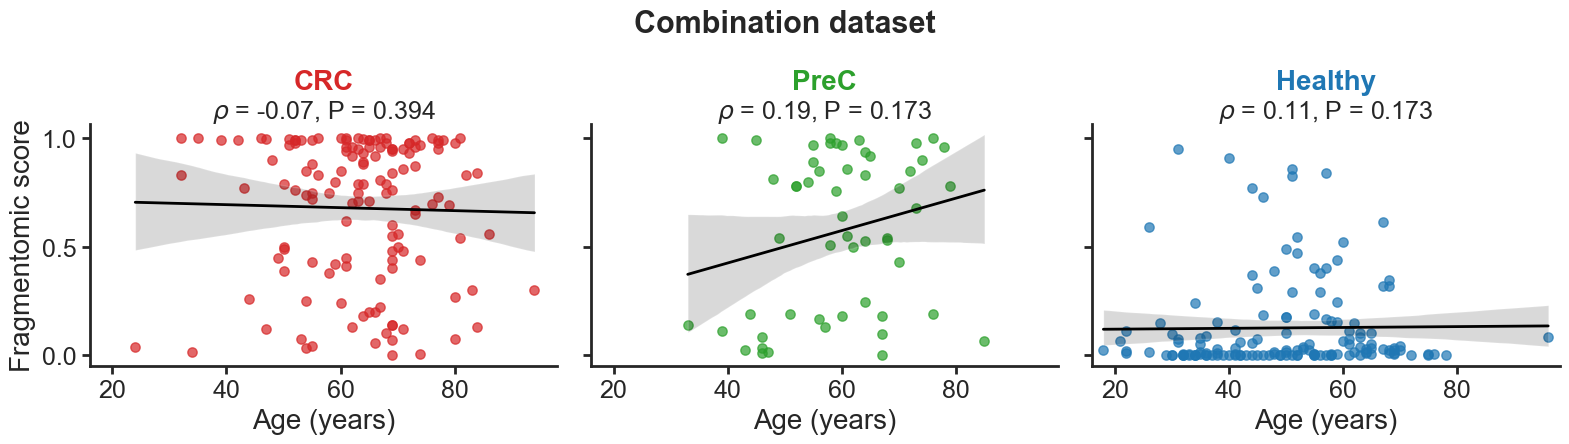

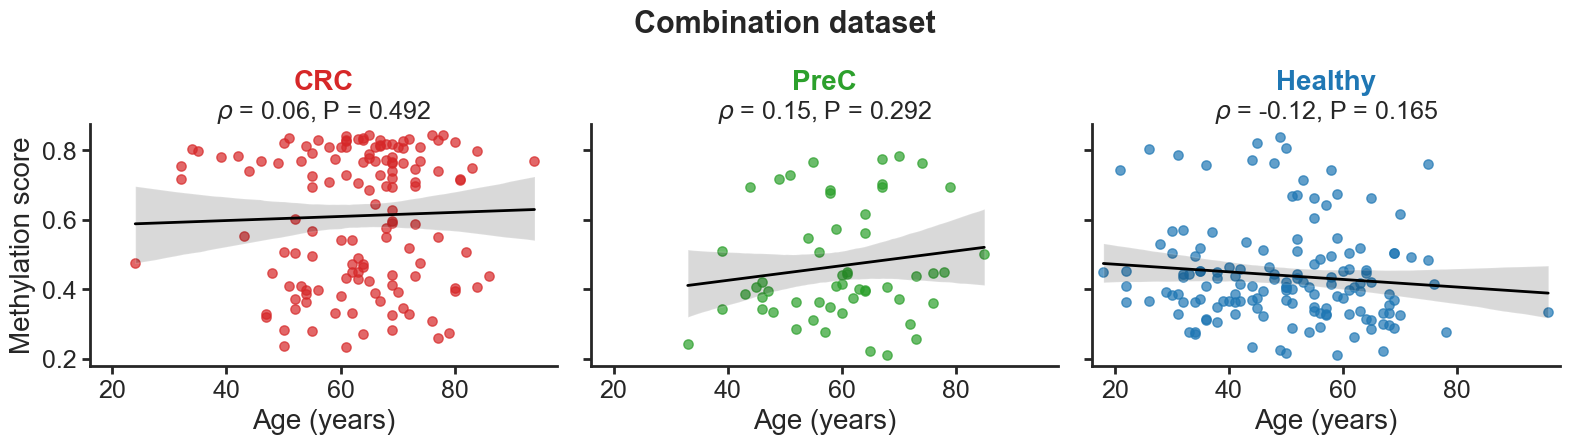

In [198]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from scipy.stats import spearmanr

mpl.rcParams["font.family"] = "Arial"

datasets = ["Combination dataset"]

scores = [
    "Fragmentomic score",
    "Methylation score"
]

class_order = ["CRC", "PreC", "Healthy"]

class_colors = {
    "CRC": "#d62728",
    "PreC": "#2ca02c",
    "Healthy": "#1f77b4"
}

for dataset in datasets:

    data_ds = df[df["Dataset all"] == dataset]

    xmin = data_ds["Age"].min() - 2
    xmax = data_ds["Age"].max() + 2

    for score in scores:

        fig, axes = plt.subplots(
            1,
            3,
            figsize=(16, 5),
            sharex=True,
            sharey=True
        )

        for ax, cls in zip(axes, class_order):

            sub = data_ds[data_ds["Class"] == cls]

            sns.regplot(
                data=sub,
                x="Age",
                y=score,
                ci=95,
                scatter_kws={
                    "s": 45,
                    "alpha": 0.7,
                    "color": class_colors[cls]
                },
                line_kws={
                    "color": "black",
                    "lw": 2
                },
                ax=ax
            )

            valid = sub[["Age", score]].dropna()

            if len(valid) >= 2:
                rho, p = spearmanr(valid["Age"], valid[score])

                if p < 0.001:
                    p_text = "P < 0.001"
                else:
                    p_text = f"P = {p:.3f}"

                stat_text = rf"$\rho$ = {rho:.2f}, {p_text}"

            else:
                stat_text = r"$\rho$ = NA"

            ax.text(
                0.5,
                1.02,
                stat_text,
                transform=ax.transAxes,
                ha="center",
                fontsize=18
            )

            ax.set_title(
                cls,
                fontsize=20,
                fontweight="bold",
                color=class_colors[cls],
                pad=25
            )

            ax.set_xlabel("Age (years)", fontsize=20)

            if ax == axes[0]:
                ax.set_ylabel(score, fontsize=20)
            else:
                ax.set_ylabel("")

            ax.set_xlim(xmin, xmax)

            ax.tick_params(
                axis="both",
                labelsize=18,
                width=2,
                length=6
            )

            ax.spines["left"].set_linewidth(2)
            ax.spines["bottom"].set_linewidth(2)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

            ax.grid(False)

        fig.suptitle(
        dataset,
        fontsize=22,
        fontweight="bold",
        y=0.9
)

        plt.tight_layout(rect=[0, 0, 1, 0.94])
        plt.show()

Performnace stratify by gender

C:\Users\VANTHITUONGVI\AppData\Local\Temp\ipykernel_31860\1666152654.py:67: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


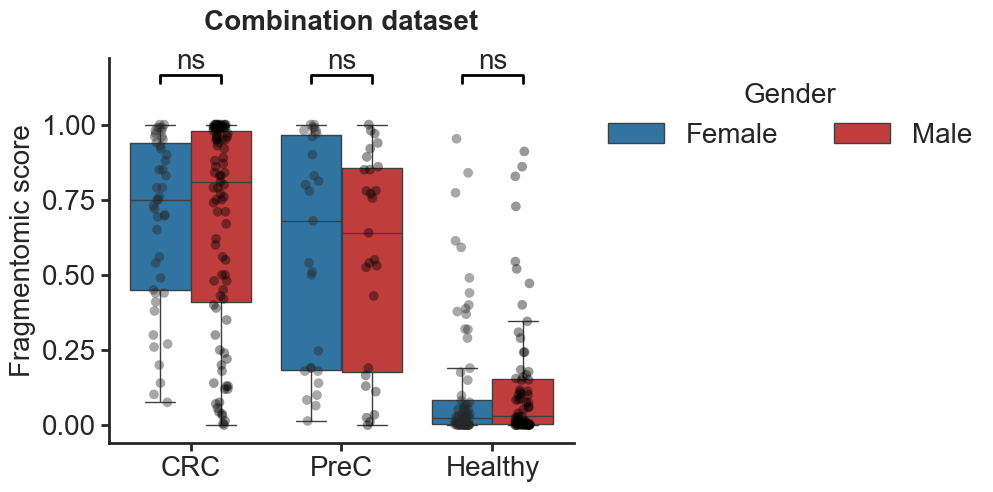

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Arial'
# ---------------------------
# Style
# ---------------------------
sns.set(style="ticks", font_scale=1.2)

# ---------------------------
# Data
# ---------------------------
df = df.copy()

# 🔥 Đảm bảo cột Gender không bị NA
df = df.dropna(subset=['Gender'])

# 🔥 Convert score → binary using cutoff = 0.5
df['Score_group'] = df['Fragmentomic score'].apply(lambda x: 'High' if x >= 0.568 else 'Low')

class_order = ['CRC','PreC','Healthy']

# 🔥 Tự động lấy gender order (tránh hardcode sai)
gender_order = sorted(df['Gender'].dropna().unique())

# ---------------------------
# p → star
# ---------------------------
def p_to_star(p):
    if pd.isna(p):
        return ''
    elif p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'ns'

# ---------------------------
# Plot function
# ---------------------------
def plot_class_gender(data, title):
    
    fig, ax = plt.subplots(figsize=(6,5))
    
    # ---------------------------
    # Boxplot
    # ---------------------------
    sns.boxplot(
        data=data,
        x='Class',
        y='Fragmentomic score',
        hue='Gender',
        order=class_order,
        hue_order=gender_order,
        palette={'Female': '#1f77b4', 'Male': '#d62728'},
        showfliers=False,
        ax=ax
    )
    
    # Points
    sns.stripplot(
        data=data,
        x='Class',
        y='Fragmentomic score',
        hue='Gender',
        order=class_order,
        hue_order=gender_order,
        dodge=True,
        color='black',
        alpha=0.4,
        size=7,
        jitter=True,
        ax=ax
    )
    
    # ---------------------------
    # Chi-square per class
    # ---------------------------
    y_min, y_max = ax.get_ylim()
    h = (y_max - y_min) * 0.08
    
    for j, cls in enumerate(class_order):
        sub = data[data['Class'] == cls].copy()
        sub = sub.dropna(subset=['Score_group', 'Gender'])
        
        if sub.shape[0] > 0:
            contingency = pd.crosstab(sub['Gender'], sub['Score_group'])
            
            if contingency.shape == (2, 2):
                _, p, _, _ = chi2_contingency(contingency)
            else:
                p = float('nan')
        else:
            p = float('nan')
        
        star = p_to_star(p)
        
        if star != '':
            x = j
            y = y_max + h
            
            ax.plot([x-0.2, x-0.2, x+0.2, x+0.2],
                    [y, y+h*0.3, y+h*0.3, y],
                    lw=2, c='black')
            
            ax.text(x, y + h*0.3, star,
                    ha='center', va='bottom', fontsize=20)
    
    # ---------------------------
    # Labels
    # ---------------------------
    ax.set_title('Combination dataset', pad=20, fontsize=20, fontweight='bold')
    ax.set_xlabel('', fontsize=20)
    ax.set_ylabel('Fragmentomic score', fontsize=20)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)


    plt.tick_params(axis='both', labelsize=20, width=2,length=6)

    for spine in ['left', 'bottom']:
            plt.gca().spines[spine].set_linewidth(2)  # hoặc 2.5, 3

            plt.gca().spines['top'].set_visible(False)
            plt.gca().spines['right'].set_visible(False)
    
    ax.grid(False)
    sns.despine()
    
    # ---------------------------
    # Legend (clean)
    # ---------------------------
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:len(gender_order)],
              labels[:len(gender_order)],
              title='Gender',
              frameon=False,
              bbox_to_anchor=(1.02, 1),
              ncol=2,
              fontsize=20,
              title_fontsize=20)
    return fig
    plt.tight_layout()
    plt.show()

# ---------------------------
# 2. Train
# ---------------------------
fig1=plot_class_gender(df[df['Dataset all'] == 'Combination dataset'], 'Combination dataset')

Correlation between TMD and CpG

In [642]:
import pandas as pd

In [ ]:
df_marker=pd.read_csv(r"Data_methylation_TMD_Filter_HS3ST2_SEPT9.csv")
df_marker.info()
df_marker

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   SampleID  367 non-null    object 
 1   Labcode   367 non-null    object 
 2   Class     367 non-null    object 
 3   Label     367 non-null    int64  
 4   HS3ST2    367 non-null    float64
 5   SEPT9     367 non-null    float64
dtypes: float64(2), int64(1), object(3)
memory usage: 17.3+ KB


,SampleID,Labcode,Class,Label,HS3ST2,SEPT9
0,HNCRC04,HNCRC04,CRC,1,8.08902,1.683240
1,HNCRC15,HNCRC15,CRC,1,5.35834,0.777202
2,HNCRC18,HNCRC18,CRC,1,7.38916,1.394700
3,K2AAAC82,K2AAAC82,Healthy,0,1.70316,0.000000
4,K0AAAX07,K0AAAX07,Healthy,0,2.04638,0.000000
...,...,...,...,...,...,...
362,KC86A11,R6348,PreC,1,13.03540,0.000000
363,LC087,R4703,CRC,1,5.34969,3.583620
364,LC096,R4761,PreC,1,3.69610,3.428570
365,LC159,R6110,PreC,1,4.06699,3.228350


In [ ]:
df_cpg=pd.read_csv(r"Data_methylation_cpg_Filter_HS3ST2_SEPT9.csv")
df_cpg.info()
df_cpg

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 316 entries, 0 to 315
Columns: 120 entries, SampleID to chr17:77373777-77373778
dtypes: float64(117), int64(1), object(2)
memory usage: 296.4+ KB


,SampleID,Class,Label,chr16:22814289-22814290,chr16:22814293-22814294,chr16:22814300-22814301,chr16:22814302-22814303,chr16:22814307-22814308,chr16:22814313-22814314,chr16:22814316-22814317,...,chr17:77373714-77373715,chr17:77373720-77373721,chr17:77373726-77373727,chr17:77373728-77373729,chr17:77373731-77373732,chr17:77373737-77373738,chr17:77373762-77373763,chr17:77373764-77373765,chr17:77373775-77373776,chr17:77373777-77373778
0,KA28A11,PreC,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,7.692308,0.000000
1,KB27A11,PreC,1,11.111111,0.000000,0.000000,0.000,16.000000,0.000000,8.000000,...,0.000000,33.333333,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,KC15A11,PreC,1,NaN,0.000000,0.000000,0.000,18.181818,0.000000,0.000000,...,0.000000,0.000000,3.846154,4.0,4.347826,3.846154,3.846154,0.000000,3.448276,3.448276
3,K0AAAA01,Healthy,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,K0AAAA40,Healthy,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
311,MC125A,CRC,1,NaN,NaN,NaN,NaN,0.000000,10.000000,0.000000,...,0.000000,25.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
312,MC206,CRC,1,11.764706,0.000000,0.000000,0.000,0.000000,0.000000,0.000000,...,0.000000,11.904762,2.325581,0.0,0.000000,0.000000,2.500000,0.000000,2.702703,2.857143
313,MC208,CRC,1,10.000000,18.518519,16.666667,15.625,6.060606,8.823529,8.823529,...,4.761905,19.767442,0.000000,0.0,0.000000,0.000000,0.000000,1.298701,1.315789,0.000000
314,MC211,CRC,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.030303,20.000000,3.225806,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [645]:
threshold = 0.5

meta_cols = ["SampleID", "Class", "Label"]
cpg_cols = [c for c in df_cpg.columns if c.startswith("chr")]

keep_cpg = df_cpg[cpg_cols].isna().mean() <= threshold

df_filtered = pd.concat(
    [
        df_cpg[meta_cols],
        df_cpg[cpg_cols].loc[:, keep_cpg]
    ],
    axis=1
)

In [646]:
print(f"Before: {len(cpg_cols)} CpGs")
print(f"After : {keep_cpg.sum()} CpGs")

Before: 117 CpGs
After : 80 CpGs


In [647]:
df_filtered

,SampleID,Class,Label,chr16:22814336-22814337,chr16:22814340-22814341,chr16:22814345-22814346,chr16:22814349-22814350,chr16:22814357-22814358,chr16:22814539-22814540,chr16:22814561-22814562,...,chr17:77373714-77373715,chr17:77373720-77373721,chr17:77373726-77373727,chr17:77373728-77373729,chr17:77373731-77373732,chr17:77373737-77373738,chr17:77373762-77373763,chr17:77373764-77373765,chr17:77373775-77373776,chr17:77373777-77373778
0,KA28A11,PreC,1,0.000000,15.384615,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,7.692308,0.000000
1,KB27A11,PreC,1,8.333333,0.000000,0.000000,0.000000,9.090909,23.529412,16.000000,...,0.000000,33.333333,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,KC15A11,PreC,1,0.000000,0.000000,0.000000,0.000000,0.000000,5.555556,13.636364,...,0.000000,0.000000,3.846154,4.0,4.347826,3.846154,3.846154,0.000000,3.448276,3.448276
3,K0AAAA01,Healthy,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,K0AAAA40,Healthy,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
311,MC125A,CRC,1,10.000000,NaN,0.000000,0.000000,0.000000,0.000000,7.142857,...,0.000000,25.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
312,MC206,CRC,1,0.000000,0.000000,0.000000,0.000000,15.000000,8.000000,0.000000,...,0.000000,11.904762,2.325581,0.0,0.000000,0.000000,2.500000,0.000000,2.702703,2.857143
313,MC208,CRC,1,6.521739,6.818182,8.510638,9.090909,10.638298,12.857143,6.382979,...,4.761905,19.767442,0.000000,0.0,0.000000,0.000000,0.000000,1.298701,1.315789,0.000000
314,MC211,CRC,1,9.090909,9.090909,0.000000,0.000000,8.333333,16.666667,8.000000,...,3.030303,20.000000,3.225806,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [648]:
import pandas as pd

# Copy dataframe
df_fill =df_filtered.copy()

# CpG columns
chr16_cols = [c for c in df_fill.columns if c.startswith("chr16")]
chr17_cols = [c for c in df_fill.columns if c.startswith("chr17")]

# Fill chr16
for col in chr16_cols:
    df_fill[col] = (
        df_fill.groupby("Class")[col]
        .transform(lambda x: x.fillna(x.mean()))
    )

# Fill chr17
for col in chr17_cols:
    df_fill[col] = (
        df_fill.groupby("Class")[col]
        .transform(lambda x: x.fillna(x.mean()))
    )

In [649]:
df_fill

,SampleID,Class,Label,chr16:22814336-22814337,chr16:22814340-22814341,chr16:22814345-22814346,chr16:22814349-22814350,chr16:22814357-22814358,chr16:22814539-22814540,chr16:22814561-22814562,...,chr17:77373714-77373715,chr17:77373720-77373721,chr17:77373726-77373727,chr17:77373728-77373729,chr17:77373731-77373732,chr17:77373737-77373738,chr17:77373762-77373763,chr17:77373764-77373765,chr17:77373775-77373776,chr17:77373777-77373778
0,KA28A11,PreC,1,0.000000,15.384615,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.692308,0.000000
1,KB27A11,PreC,1,8.333333,0.000000,0.000000,0.000000,9.090909,23.529412,16.000000,...,0.000000,33.333333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,KC15A11,PreC,1,0.000000,0.000000,0.000000,0.000000,0.000000,5.555556,13.636364,...,0.000000,0.000000,3.846154,4.000000,4.347826,3.846154,3.846154,0.000000,3.448276,3.448276
3,K0AAAA01,Healthy,0,3.987746,2.486831,2.583509,2.098555,5.084617,6.839587,5.589520,...,3.376660,17.954010,4.955739,1.051698,0.870450,0.343042,0.584261,0.864099,1.266906,1.656584
4,K0AAAA40,Healthy,0,3.987746,2.486831,2.583509,2.098555,5.084617,6.839587,5.589520,...,3.376660,17.954010,4.955739,1.051698,0.870450,0.343042,0.584261,0.864099,1.266906,1.656584
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
311,MC125A,CRC,1,10.000000,7.794590,0.000000,0.000000,0.000000,0.000000,7.142857,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
312,MC206,CRC,1,0.000000,0.000000,0.000000,0.000000,15.000000,8.000000,0.000000,...,0.000000,11.904762,2.325581,0.000000,0.000000,0.000000,2.500000,0.000000,2.702703,2.857143
313,MC208,CRC,1,6.521739,6.818182,8.510638,9.090909,10.638298,12.857143,6.382979,...,4.761905,19.767442,0.000000,0.000000,0.000000,0.000000,0.000000,1.298701,1.315789,0.000000
314,MC211,CRC,1,9.090909,9.090909,0.000000,0.000000,8.333333,16.666667,8.000000,...,3.030303,20.000000,3.225806,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [ ]:
import pandas as pd
from scipy.stats import pearsonr

# df_marker:
# SampleID, Labcode, Class, Label, HS3ST2, SEPT9

# df_cpg:
# SampleID, Class, Label, chr16:..., chr17:..., ...
df_cpg= df_fill
# -------------------------------------------------
# Merge
# -------------------------------------------------
df = df_marker.merge(
    df_cpg.drop(columns=["Class", "Label"], errors="ignore"),
    on="SampleID",
    how="inner"
)

# -------------------------------------------------
# CpG columns
# -------------------------------------------------
chr16_cols = [c for c in df.columns if c.startswith("chr16")]
chr17_cols = [c for c in df.columns if c.startswith("chr17")]

# -------------------------------------------------
# Function
# -------------------------------------------------
def calculate_correlations(data, marker, cpg_cols):

    results = []

    for cpg in cpg_cols:

        tmp = data[[marker, cpg]].dropna()

        if len(tmp) < 3:
            continue

        r, p = pearsonr(tmp[marker], tmp[cpg])

        results.append({
            "Marker": marker,
            "CpG": cpg,
            "N": len(tmp),
            "Pearson_r": r,
            "P_value": p
        })

    return pd.DataFrame(results)

# -------------------------------------------------
# All samples
# -------------------------------------------------
all_chr16 = calculate_correlations(df, "HS3ST2", chr16_cols)
all_chr16["Class"] = "All"

all_chr17 = calculate_correlations(df, "SEPT9", chr17_cols)
all_chr17["Class"] = "All"

# -------------------------------------------------
# Stratified by Class
# -------------------------------------------------
results = [all_chr16, all_chr17]

for cls in df["Class"].unique():

    sub = df[df["Class"] == cls]

    res16 = calculate_correlations(sub, "HS3ST2", chr16_cols)
    res16["Class"] = cls

    res17 = calculate_correlations(sub, "SEPT9", chr17_cols)
    res17["Class"] = cls

    results.extend([res16, res17])

# -------------------------------------------------
# Final table
# -------------------------------------------------
correlation_df = pd.concat(results, ignore_index=True)

correlation_df = correlation_df[
    ["Class", "Marker", "CpG", "N", "Pearson_r", "P_value"]
]

# Sort by absolute correlation
correlation_df = correlation_df.sort_values(
    "Pearson_r",
    key=lambda x: x.abs(),
    ascending=False
)

print(correlation_df.head())

# Save
correlation_df.to_csv("HS3ST2_SEPT9_CpG_plot.csv", index=False)

    Class Marker                      CpG   N  Pearson_r       P_value
292  PreC  SEPT9  chr17:77373480-77373481  20   0.984833  3.819181e-15
299  PreC  SEPT9  chr17:77373548-77373549  20   0.984187  5.545755e-15
317  PreC  SEPT9  chr17:77373764-77373765  20   0.983336  8.861748e-15
289  PreC  SEPT9  chr17:77373471-77373472  20   0.982568  1.325621e-14
298  PreC  SEPT9  chr17:77373541-77373542  20   0.980643  3.378379e-14


In [651]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import seaborn as sns
import matplotlib.pyplot as plt

# =====================================
# Merge two dataframes
# =====================================
df = df_marker.merge(
    df_cpg.drop(columns=["Class", "Label"], errors="ignore"),
    on="SampleID",
    how="inner"
)

# =====================================
# CpG columns
# =====================================
chr16_cols = [c for c in df.columns if c.startswith("chr16")]
chr17_cols = [c for c in df.columns if c.startswith("chr17")]

groups = {
    "All": df,
    "Healthy": df[df["Class"] == "Healthy"],
    "PreC": df[df["Class"] == "PreC"],
    "CRC": df[df["Class"] == "CRC"],
}

# =====================================
# Function
# =====================================
def correlation_matrix(marker, cpg_cols):

    corr_df = pd.DataFrame(index=cpg_cols)

    for group_name, sub in groups.items():

        values = []

        for cpg in cpg_cols:

            tmp = sub[[marker, cpg]].dropna()

            if len(tmp) < 3:
                values.append(np.nan)
            else:
                r, _ = pearsonr(tmp[marker], tmp[cpg])
                values.append(r)

        corr_df[group_name] = values

    corr_df.index.name = "CpG"

    return corr_df

# =====================================
# Calculate
# =====================================
hs3_corr = correlation_matrix("HS3ST2", chr16_cols)
sept9_corr = correlation_matrix("SEPT9", chr17_cols)

# =====================================
# Sort by overall correlation
# =====================================
hs3_corr = hs3_corr.sort_values("All", ascending=False)
sept9_corr = sept9_corr.sort_values("All", ascending=False)

Heatmap_select CpG

In [ ]:
df=pd.read_csv(r"HS3ST2_SEPT9_CpG_plot.csv")
df.info()
df

C:\Users\VANTHITUONGVI\AppData\Local\Temp\ipykernel_31860\1359760778.py:84: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


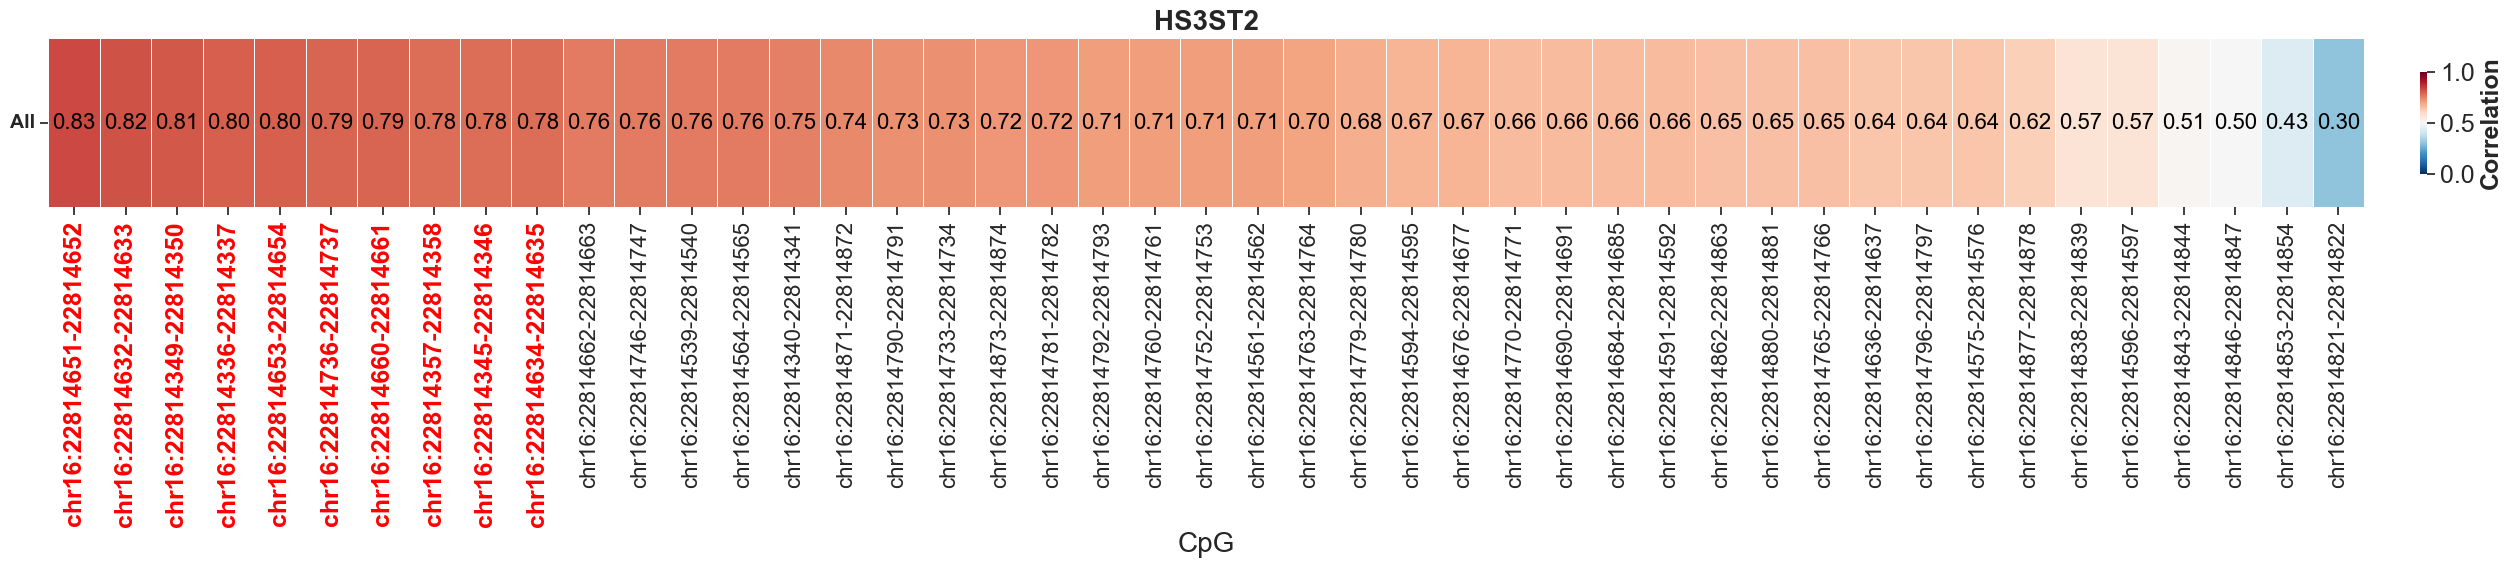

C:\Users\VANTHITUONGVI\AppData\Local\Temp\ipykernel_31860\1359760778.py:84: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


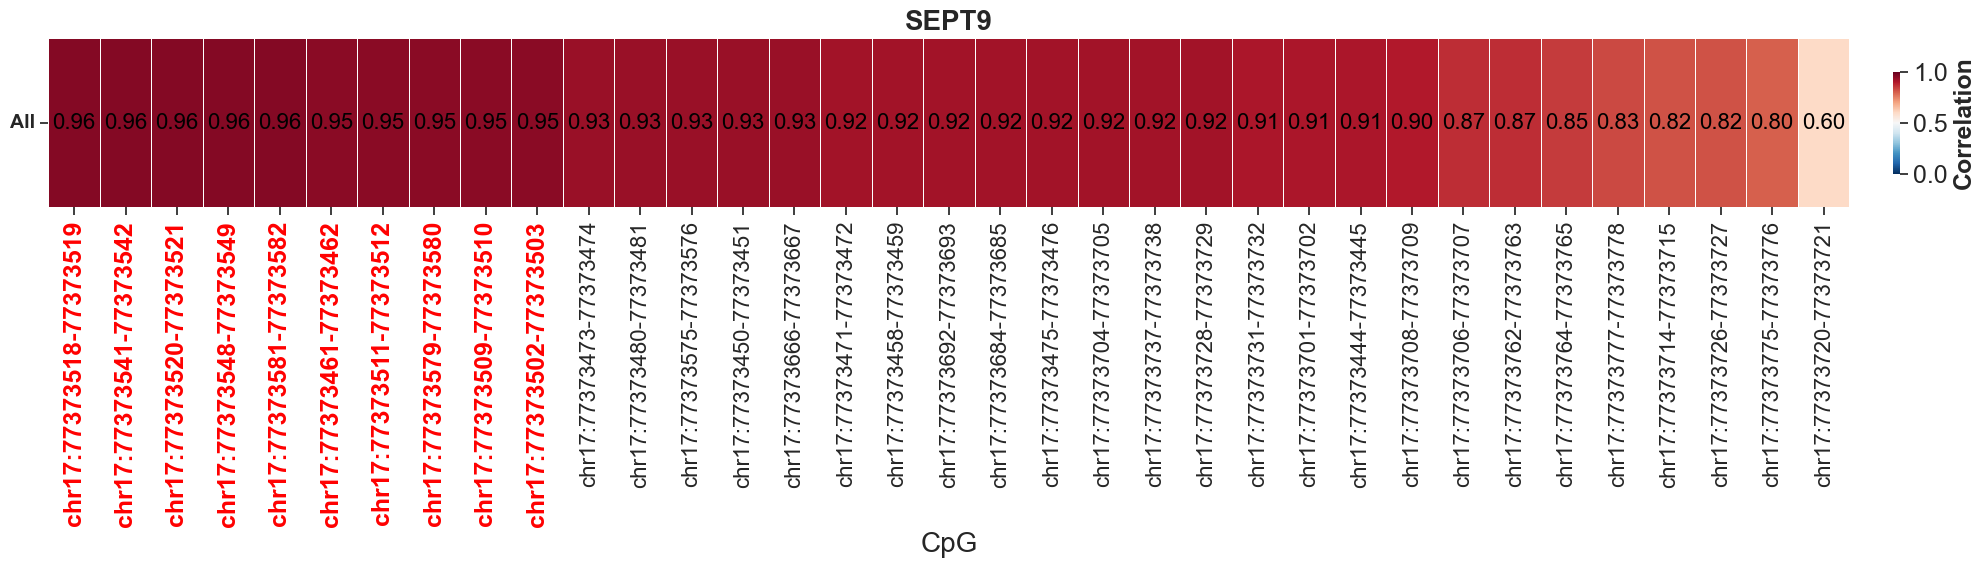

In [658]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# Plot one heatmap for each marker
# ==========================================
for marker, sub in df.groupby("Marker"):

    # Sort CpGs by genomic order (or use "All" if you prefer)
    sub = sub.copy()

    # Top 10 CpGs based on All
    top10_cpg = (
        sub.nlargest(10, "All")["CpG"]
        .astype(str)
        .tolist()
    )

    # Heatmap data (horizontal)
    heatmap_data = (
        sub.set_index("CpG")[["All"]]
        .T
    )

    plt.figure(figsize=(max(8, len(sub) * 0.8), 2.2))

    ax = sns.heatmap(
        heatmap_data,
        cmap="RdBu_r",
        annot=True,
        annot_kws={
        "size": 16,
        "color": "black",      # màu chữ annotation
    },
        fmt=".2f",
        linewidths=0.5,
        vmin=0,
        vmax=1,
        cbar_kws={
        "label": "Correlation",
        "shrink": 0.6,
        "aspect": 15,   # số nhỏ hơn -> colorbar dày hơn
        "pad": 0.02}
    )
        # Colorbar
    cbar = ax.collections[0].colorbar

    # Label của colorbar
    cbar.set_label(
        "Correlation",
        fontsize=18,
        fontweight="bold"
    )

    # Tick labels của colorbar
    cbar.ax.tick_params(labelsize=18)

    # ==========================================
    # Highlight Top 10 CpGs
    # ==========================================
    for tick in ax.get_xticklabels():
        if tick.get_text() in top10_cpg:
            tick.set_fontweight("bold")
            tick.set_color("red")
            tick.set_fontsize(18)
        else:
            tick.set_fontsize(16)

    # Y-axis ("All")
    ax.set_yticklabels(
        ax.get_yticklabels(),
        rotation=0,
        fontsize=14,
        fontweight="bold"
    )

    plt.title(marker, fontsize=20, fontweight="bold")
    plt.xlabel("CpG", fontsize = 20)
    plt.ylabel("",  fontsize= 20)

    plt.xticks(rotation=90)

    plt.tight_layout()
    plt.show()

Performance combination model

In [ ]:
df=pd.read_csv(r"Compare prediction_Frag_Combine score.csv",sep=',')
df.info()
df

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.contingency_tables import mcnemar
from matplotlib.ticker import MultipleLocator
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Arial'

df = df.copy()

# =========================
# THRESHOLD
# =========================
df["Fragmentomic score"] = (df["Fragmentomic score"] > 0).astype(int)
df["Methylation score"] = (df["Methylation score"] > 0).astype(int)
df["Combination model"] = (df["Combination score"] > 0).astype(int)

models = ["Fragmentomic score", "Methylation score", "Combination model"]

# =========================
# SEM
# =========================
def compute_mean_sem(sub_df, model):
    vals = (sub_df[model] == sub_df['Label']).astype(int)
    mean = np.mean(vals) * 100
    sem = np.std(vals, ddof=1) / np.sqrt(len(vals)) * 100
    return mean, mean - sem, mean + sem

# =========================
# MCNEMAR
# =========================
def mcnemar_test(sub_df, m1, m2):
    a = sub_df[m1] == sub_df["Label"]
    b = sub_df[m2] == sub_df["Label"]
    b_only = np.sum(a & ~b)
    c_only = np.sum(~a & b)
    table = [[0, b_only], [c_only, 0]]
    return mcnemar(table, exact=False, correction=False).pvalue

def star(p):
    if p < 0.001: return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    else: return "ns"

# =========================
# PLOT
# =========================
def plot_dataset(df_sub, title):

    metric_defs = {
        "Specificity": df_sub[df_sub['Label'] == 0],
        "Sensitivity_PreC": df_sub[df_sub['Class'] == 'PreC'],
        "Sensitivity_CRC": df_sub[df_sub['Class'] == 'CRC'],
        "Sensitivity Overall": df_sub[df_sub['Label'] == 1],
    }

    metrics = list(metric_defs.keys())
    n_dict = {k: len(v) for k, v in metric_defs.items()}

    plot_data = []
    for metric, sub_df in metric_defs.items():
        for m in models:
            mean, low, high = compute_mean_sem(sub_df, m)
            plot_data.append({
                "Metric": metric,
                "Model": m,
                "Mean": mean,
                "Low": low,
                "High": high
            })

    plot_df = pd.DataFrame(plot_data)

    sns.set(style="ticks")
    plt.figure(figsize=(15,8))

    palette = {
            "Fragmentomic score": "#99BCE0",
            "Methylation score": "#99CC99",
            "Combination model": "#E0BBE4"
        }

    ax = sns.barplot(
        data=plot_df,
        x="Metric",
        y="Mean",
        hue="Model",
        ci=None,
        palette=palette
    )

    offset = {
        "Fragmentomic score": -0.25,
        "Methylation score": 0,
        "Combination model": 0.25
    }

    global_max = 0

    # =========================
    # ERROR BAR + VALUE
    # =========================
    for _, row in plot_df.iterrows():
        x = metrics.index(row["Metric"])
        xpos = x + offset[row["Model"]]

        lower = row["Mean"] - row["Low"]
        upper = row["High"] - row["Mean"]

        ax.errorbar(xpos, row["Mean"],
                    yerr=[[lower],[upper]],
                    fmt='none', capsize=4, color='black')

        ax.scatter(xpos, row["Mean"],
                   color='red', s=40, edgecolor='black', zorder=5)

        # value
        ax.text(xpos, row["High"] + 0.8,
                f"{row['Mean']:.1f}%",
                ha='center', fontsize=18)

        # sample size
        ax.text(xpos, row["Mean"]/2 - 1,
                f"{n_dict[row['Metric']]}",
                ha='center', fontsize=18)

        global_max = max(global_max, row["High"])

    # =========================
    # SIGNIFICANCE
    # =========================
    for i, metric in enumerate(metrics):
        sub_df = metric_defs[metric]

        p_fm = mcnemar_test(sub_df, "Fragmentomic score", "Combination model")
        p_meth = mcnemar_test(sub_df, "Methylation score", "Combination model")

        x_fm = i + offset["Fragmentomic score"]
        x_meth = i + offset["Methylation score"]
        x_combo = i + offset["Combination model"]

        base = global_max + 5 + i*0.3
        h = 1.2

        # FM vs Combo
        ax.plot([x_fm,x_fm,x_combo,x_combo],
                [base+5, base+5+h, base+5+h, base+5],
                color='black')
        ax.text((x_fm+x_combo)/2,
                base+5+h+0.3,
                star(p_fm), ha='center',fontsize=18)

        # Meth vs Combo
        ax.plot([x_meth,x_meth,x_combo,x_combo],
                [base, base+h, base+h, base],
                color='black')
        ax.text((x_meth+x_combo)/2,
                base+h+0.3,
                star(p_meth), ha='center',fontsize=18)

    # =========================
    # FORMAT
    # =========================
    ax.set_title(title, fontsize=20, fontweight='bold')
    ax.set_ylabel("Percentage (%)", fontsize=18)
    ax.set_xlabel("")

    # ✅ LEGEND dưới plot
    ax.legend(
        loc='upper center',
        bbox_to_anchor=(0.5, -0.15),
        ncol=3,
        frameon=False, fontsize=18
    )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tick_params(axis='both', labelsize=18, width=2,length=6)

    for spine in ['left', 'bottom']:
            plt.gca().spines[spine].set_linewidth(2)  # hoặc 2.5, 3

            plt.gca().spines['top'].set_visible(False)
            plt.gca().spines['right'].set_visible(False)


    # ax.yaxis.set_major_locator(MultipleLocator(10))
    # ax.tick_params(axis='y', length=5, width=1, left=True)
    # # ax.tick_params(axis='x', fontsize=18)
    # ax.spines['left'].set_visible(True)

    # ax.set_ylim(0, global_max + 15)

    # tránh bị cắt legend
    plt.subplots_adjust(bottom=0.2)

    plt.show()

# =========================
# RUN
# =========================
plot_dataset(df[df["Dataset"]=="Train"], "Combination - Training Set")
plot_dataset(df[df["Dataset"]=="Test"], "Combination - Test Set")

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.contingency_tables import mcnemar
from matplotlib.ticker import MultipleLocator
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Arial'

df = df.copy()

# =========================
# THRESHOLD
# =========================
df["Fragmentomic score"] = (df["Fragmentomic score"] > 0).astype(int)
df["Methylation score"] = (df["Methylation score"] > 0).astype(int)
df["Combination score"] = (df["Combination score"] > 0).astype(int)

models = ["Fragmentomic score", "Methylation score", "Combination score"]

# =========================
# SEM
# =========================
def compute_mean_sem(sub_df, model):
    vals = (sub_df[model] == sub_df['Label']).astype(int)
    mean = np.mean(vals) * 100
    sem = np.std(vals, ddof=1) / np.sqrt(len(vals)) * 100
    return mean, mean - sem, mean + sem

# =========================
# MCNEMAR
# =========================
def mcnemar_test(sub_df, m1, m2):
    a = sub_df[m1] == sub_df["Label"]
    b = sub_df[m2] == sub_df["Label"]
    b_only = np.sum(a & ~b)
    c_only = np.sum(~a & b)
    table = [[0, b_only], [c_only, 0]]
    return mcnemar(table, exact=False, correction=False).pvalue

def star(p):
    if p < 0.001: return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    else: return "ns"

# =========================
# PLOT
# =========================
def plot_dataset(df_sub, title):

    # =========================
    # GROUPS
    # =========================
    metric_defs = {

        # "PreK": df_sub[
        #     df_sub["Class"] == "PreK"
        # ],

        # "CRC": df_sub[
        #     df_sub["Class"] == "CRC"
        # ],

        "Stage I-II": df_sub[
            df_sub["Stage"].isin(
                ["Stage I", "Stage II"]
            )
        ],

        "Stage III": df_sub[
            df_sub["Stage"] == "Stage III"
        ],

        "Unknown stage": df_sub[
            df_sub["Stage"] == "Unknown stage"
        ]
    }

    metrics = list(metric_defs.keys())
    n_dict = {k: len(v) for k, v in metric_defs.items()}

    plot_data = []
    for metric, sub_df in metric_defs.items():
        for m in models:
            mean, low, high = compute_mean_sem(sub_df, m)
            plot_data.append({
                "Metric": metric,
                "Model": m,
                "Mean": mean,
                "Low": low,
                "High": high
            })

    plot_df = pd.DataFrame(plot_data)

    sns.set(style="ticks")
    plt.figure(figsize=(12,8))

    palette = {
               "Fragmentomic score": "#99BCE0",
               "Methylation score": "#99CC99",
               "Combination score": "#E0BBE4"
           }

    ax = sns.barplot(
        data=plot_df,
        x="Metric",
        y="Mean",
        hue="Model",
        ci=None,
        palette=palette
    )

    offset = {
        "Fragmentomic score": -0.25,
        "Methylation score": 0,
        "Combination score": 0.25
    }

    global_max = 0

    # =========================
    # ERROR BAR + VALUE
    # =========================
    for _, row in plot_df.iterrows():
        x = metrics.index(row["Metric"])
        xpos = x + offset[row["Model"]]

        lower = row["Mean"] - row["Low"]
        upper = row["High"] - row["Mean"]

        ax.errorbar(xpos, row["Mean"],
                    yerr=[[lower],[upper]],
                    fmt='none', capsize=4, color='black')

        ax.scatter(xpos, row["Mean"],
                   color='red', s=40, edgecolor='black', zorder=5)

        # value
        ax.text(xpos, row["High"] + 0.8,
                f"{row['Mean']:.1f}%",
                ha='center', fontsize=16)

        # sample size
        ax.text(xpos, row["Mean"]/2 - 1,
                f"{n_dict[row['Metric']]}",
                ha='center', fontsize=16)

        global_max = max(global_max, row["High"])

    # =========================
    # SIGNIFICANCE
    # =========================
    for i, metric in enumerate(metrics):
        sub_df = metric_defs[metric]

        p_fm = mcnemar_test(sub_df, "Fragmentomic score", "Combination score")
        p_meth = mcnemar_test(sub_df, "Methylation score", "Combination score")

        x_fm = i + offset["Fragmentomic score"]
        x_meth = i + offset["Methylation score"]
        x_combo = i + offset["Combination score"]

        base = global_max + 5 + i*0.3
        h = 1.2

        # FM vs Combo
        ax.plot([x_fm,x_fm,x_combo,x_combo],
                [base+5, base+5+h, base+5+h, base+5],
                color='black')
        ax.text((x_fm+x_combo)/2,
                base+5+h+0.3,
                star(p_fm), ha='center',fontsize=18)

        # Meth vs Combo
        ax.plot([x_meth,x_meth,x_combo,x_combo],
                [base, base+h, base+h, base],
                color='black')
        ax.text((x_meth+x_combo)/2,
                base+h+0.3,
                star(p_meth), ha='center',fontsize=18)

    # =========================
    # FORMAT
    # =========================
    ax.set_title(title, fontsize=20, fontweight='bold')
    ax.set_ylabel("Percentage (%)", fontsize=18)
    ax.set_xlabel("")

    # ✅ LEGEND dưới plot
    ax.legend(
        loc='upper center',
        bbox_to_anchor=(0.5, -0.15),
        ncol=3,
        frameon=False, fontsize=18
    )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    
    plt.tick_params(axis='both', labelsize=18, width=2,length=6)

    for spine in ['left', 'bottom']:
            plt.gca().spines[spine].set_linewidth(2)  # hoặc 2.5, 3

            plt.gca().spines['top'].set_visible(False)
            plt.gca().spines['right'].set_visible(False)


    # ax.yaxis.set_major_locator(MultipleLocator(10))
    # ax.tick_params(axis='y', length=5, width=1, left=True)
    # # ax.tick_params(axis='x', fontsize=18)
    # ax.spines['left'].set_visible(True)

    # ax.set_ylim(0, global_max + 15)

    # tránh bị cắt legend
    plt.subplots_adjust(bottom=0.2)

    plt.show()

# =========================
# RUN
# =========================
plot_dataset(df[df["Dataset"]=="Train"], "Combination - Training Set")
plot_dataset(df[df["Dataset"]=="Test"], "Combination - Test Set")